In [834]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [835]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [836]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [837]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [838]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [839]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [840]:
df.shape

(1470, 35)

In [841]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [842]:
df.isnull().sum().sum()

0

In [843]:
df.duplicated().sum()

0

In [844]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [845]:
num_cols = df.select_dtypes(include = ['int64', 'float64']).columns

In [846]:
cat_cols = df.select_dtypes(include = ['object']).columns

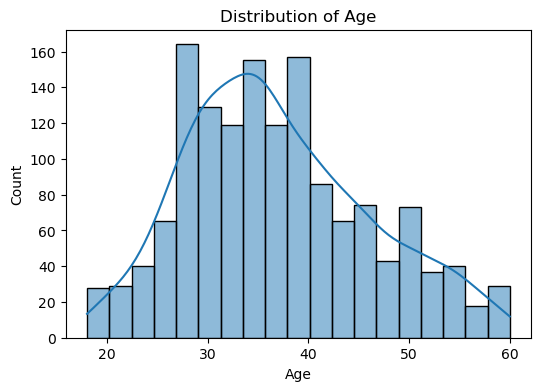

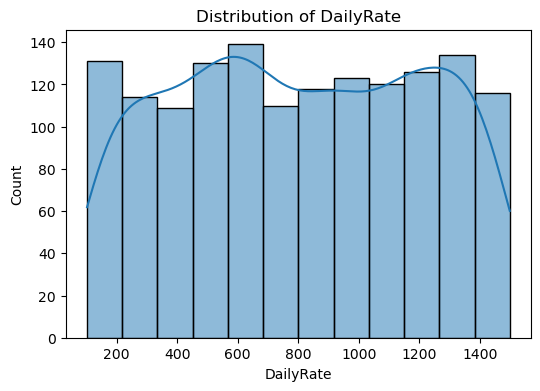

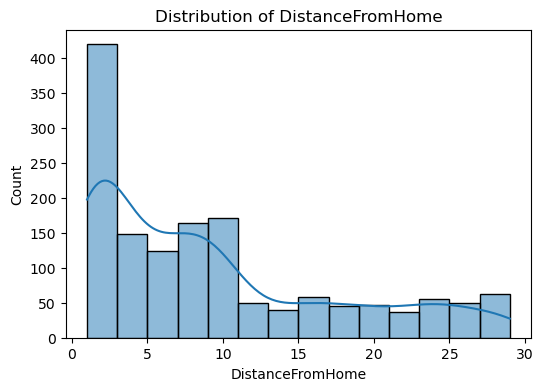

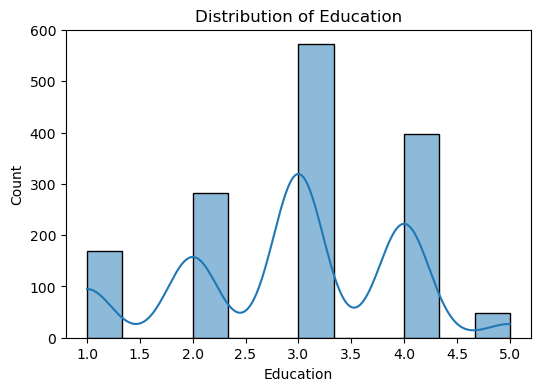

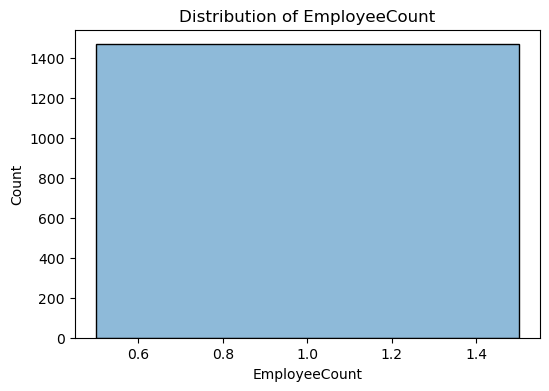

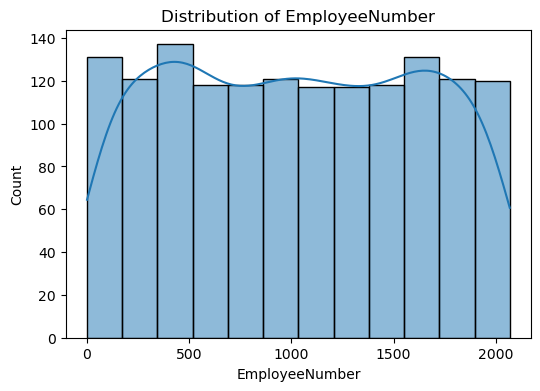

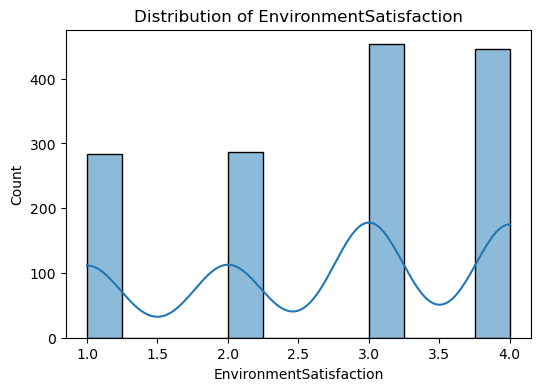

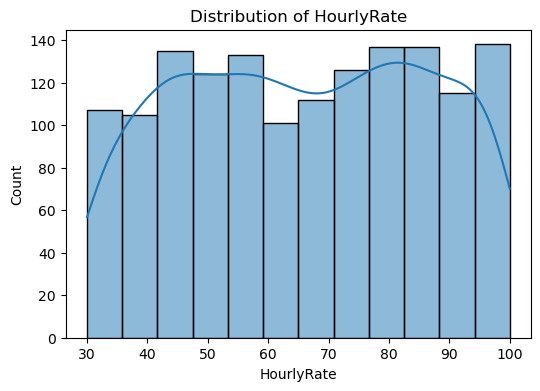

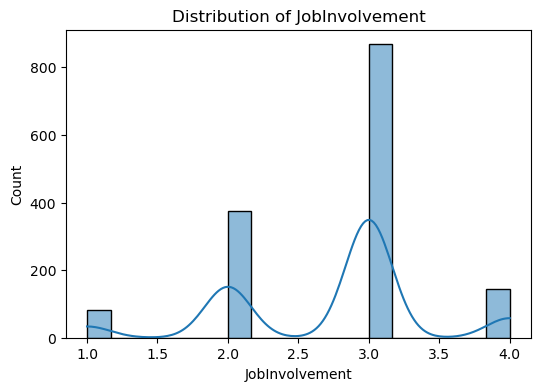

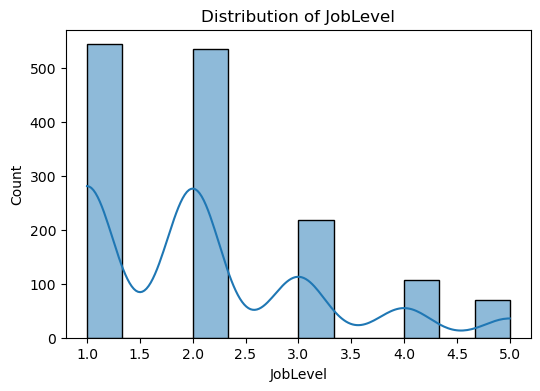

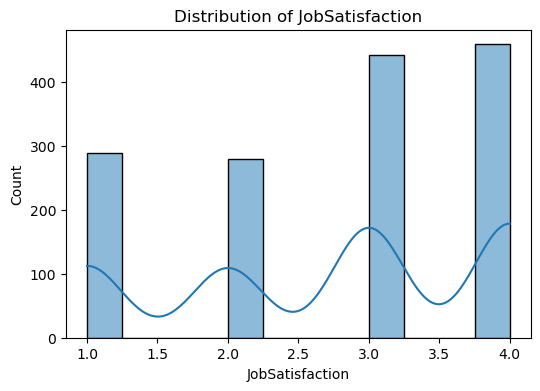

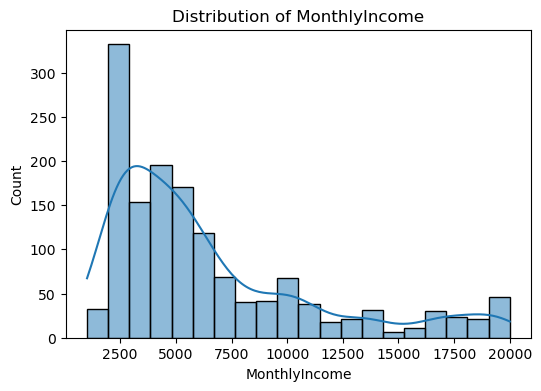

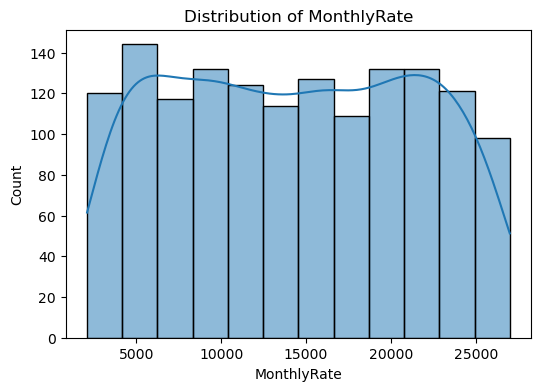

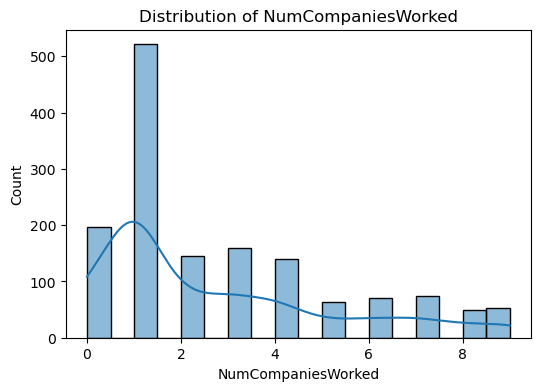

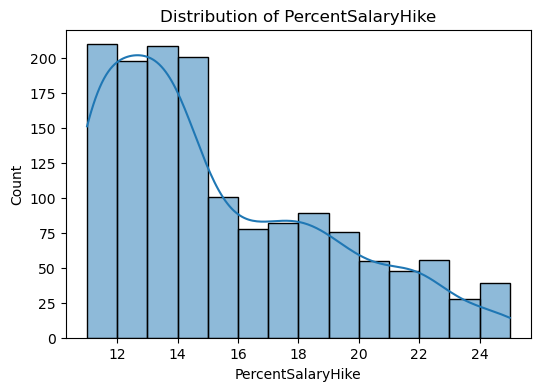

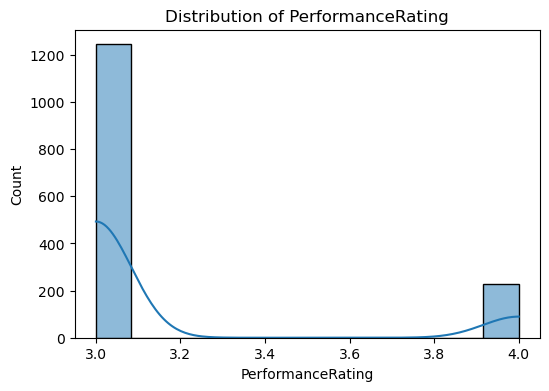

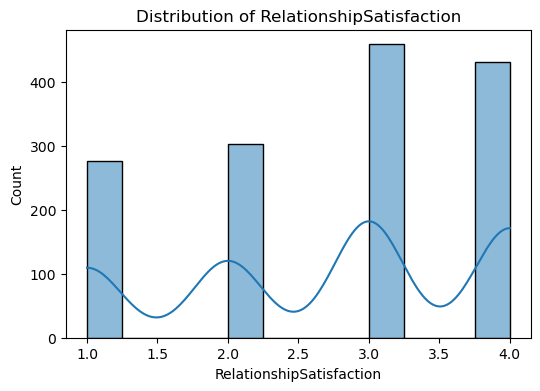

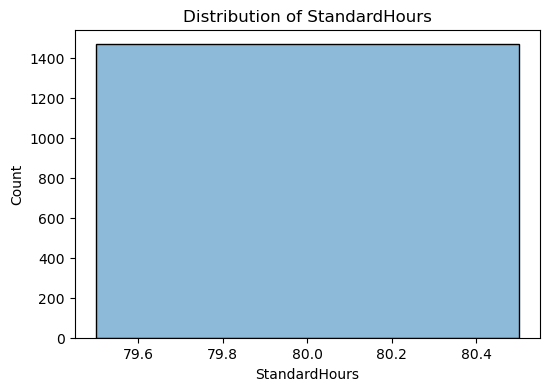

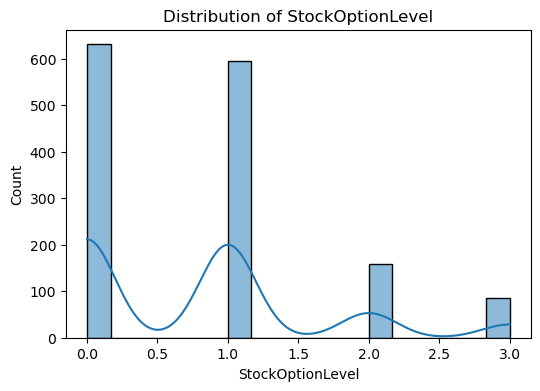

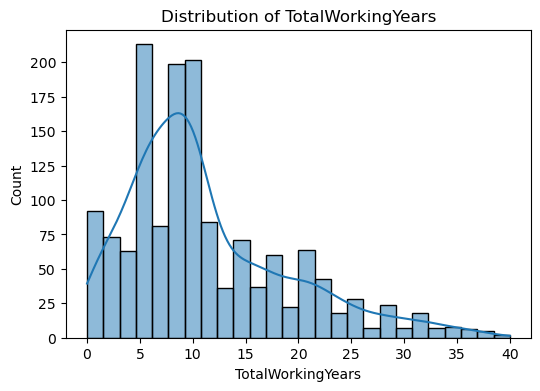

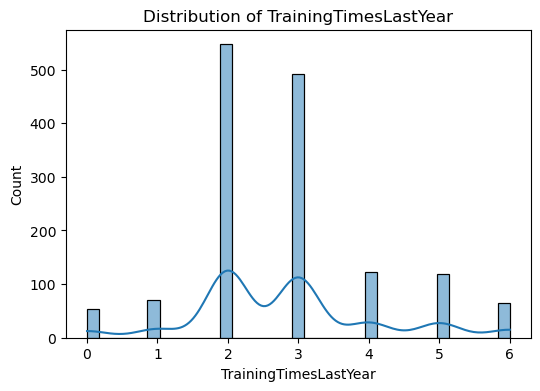

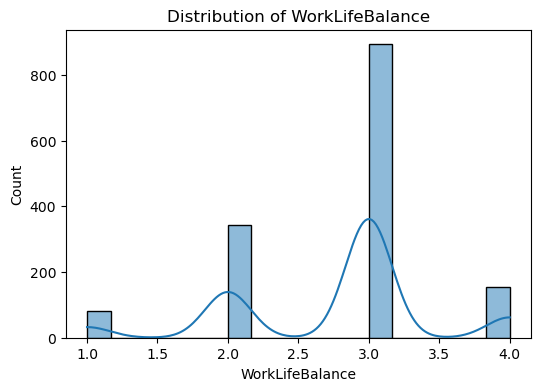

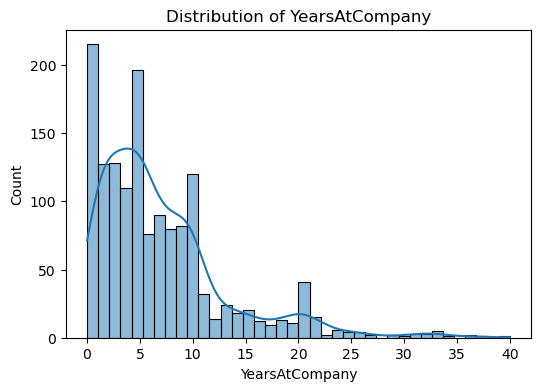

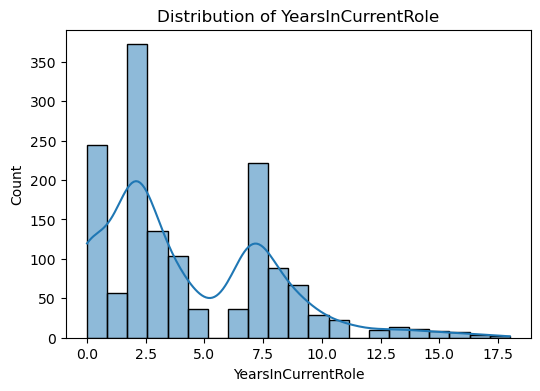

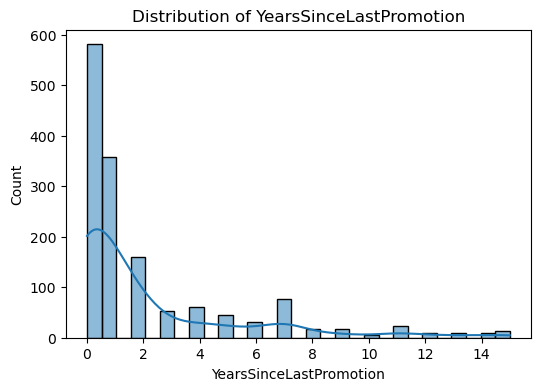

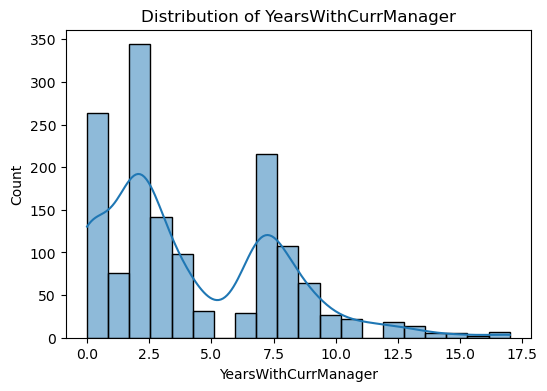

In [847]:
for i in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[i], kde=True)
    plt.title(f'Distribution of {i}')
    plt.show()

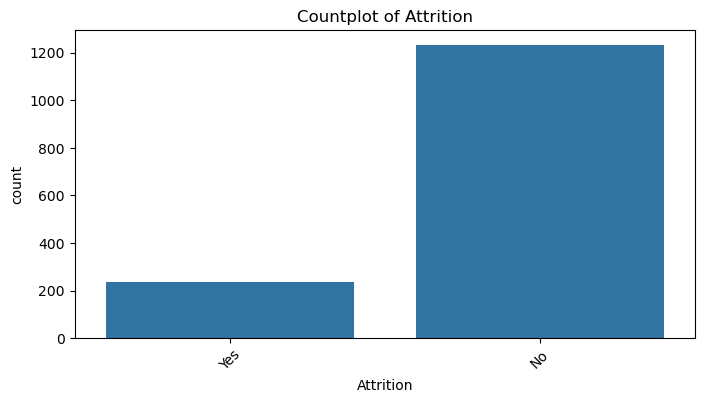

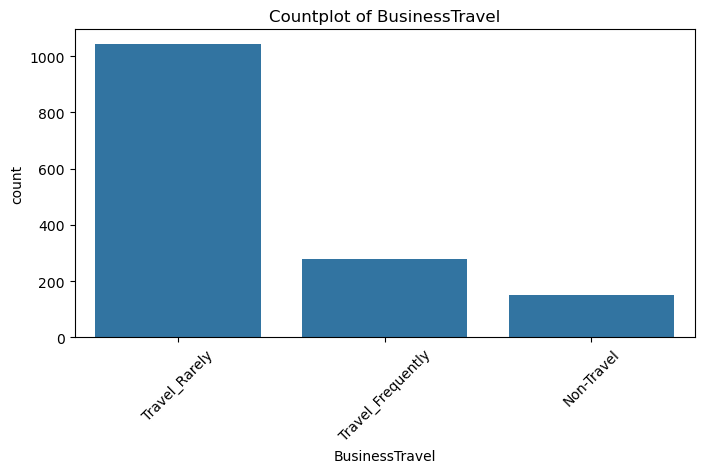

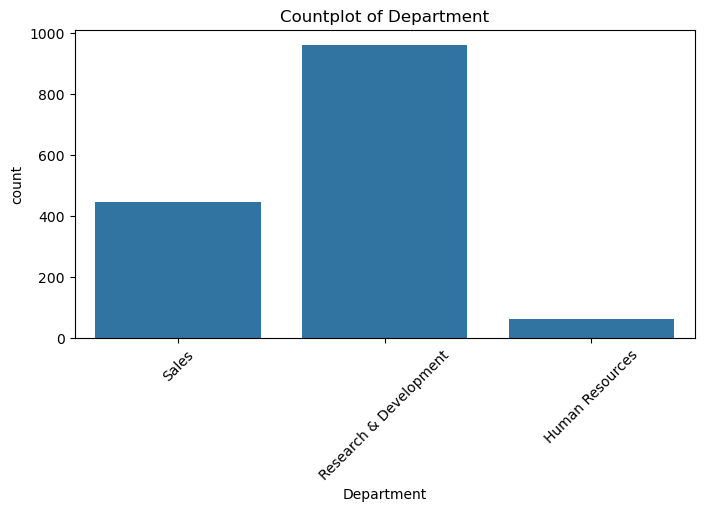

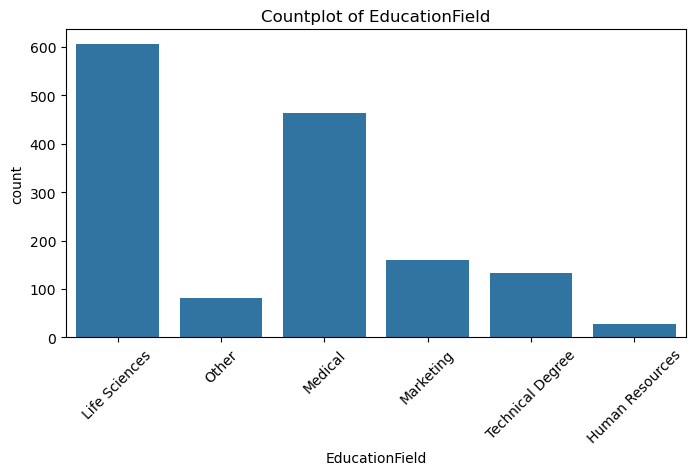

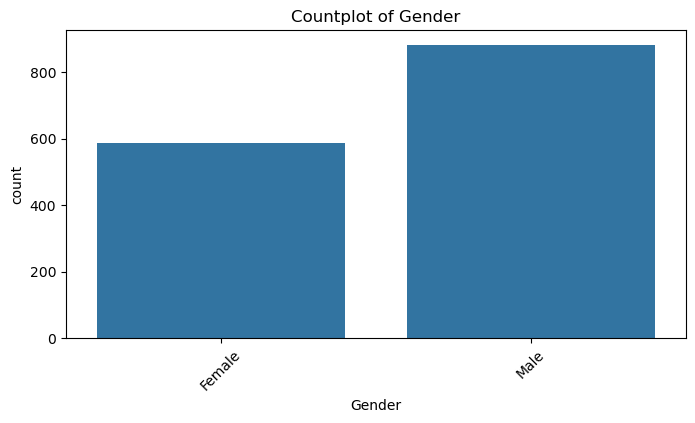

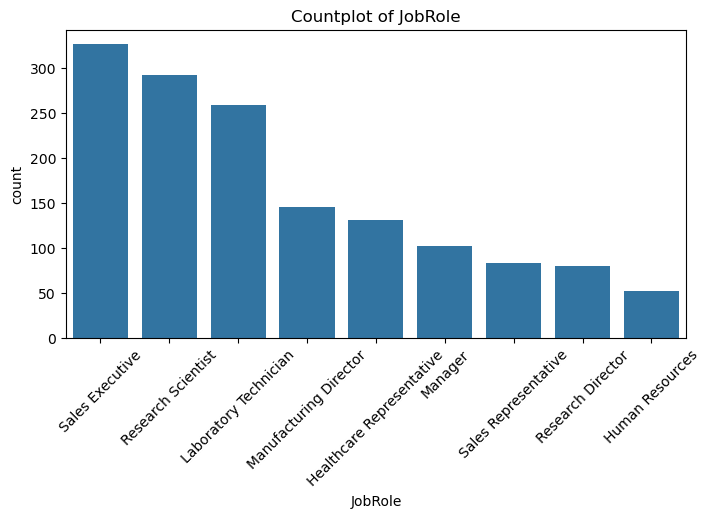

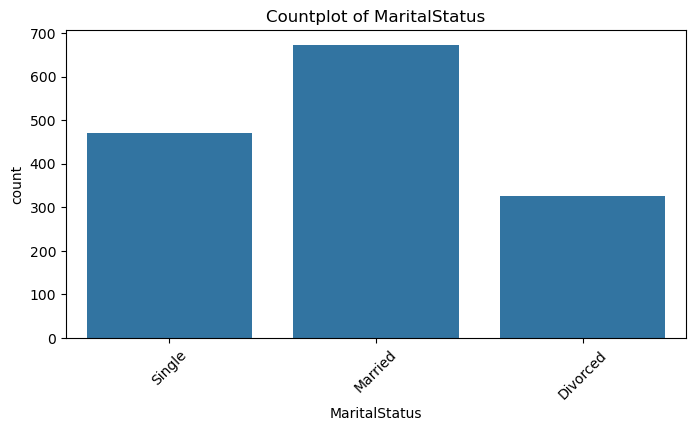

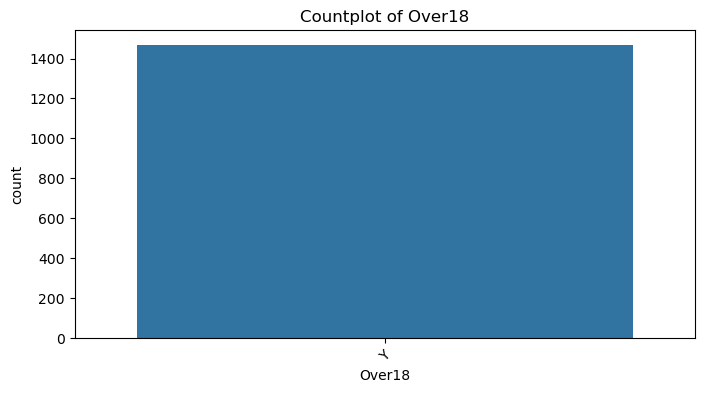

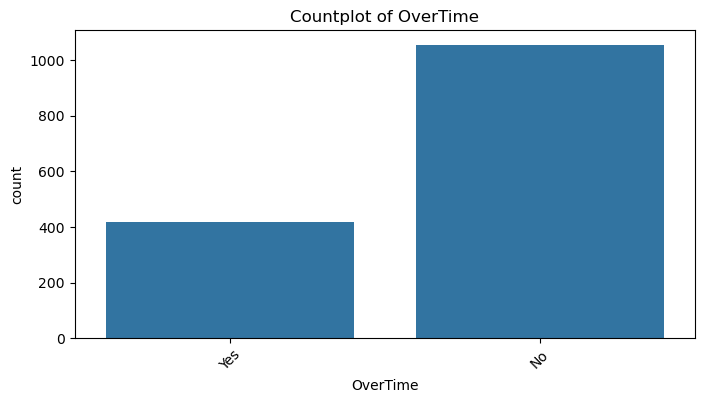

In [848]:
for i in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[i])
    plt.title(f'Countplot of {i}')
    plt.xticks(rotation=45)
    plt.show()

In [849]:
df.corr(numeric_only=True)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,...,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281


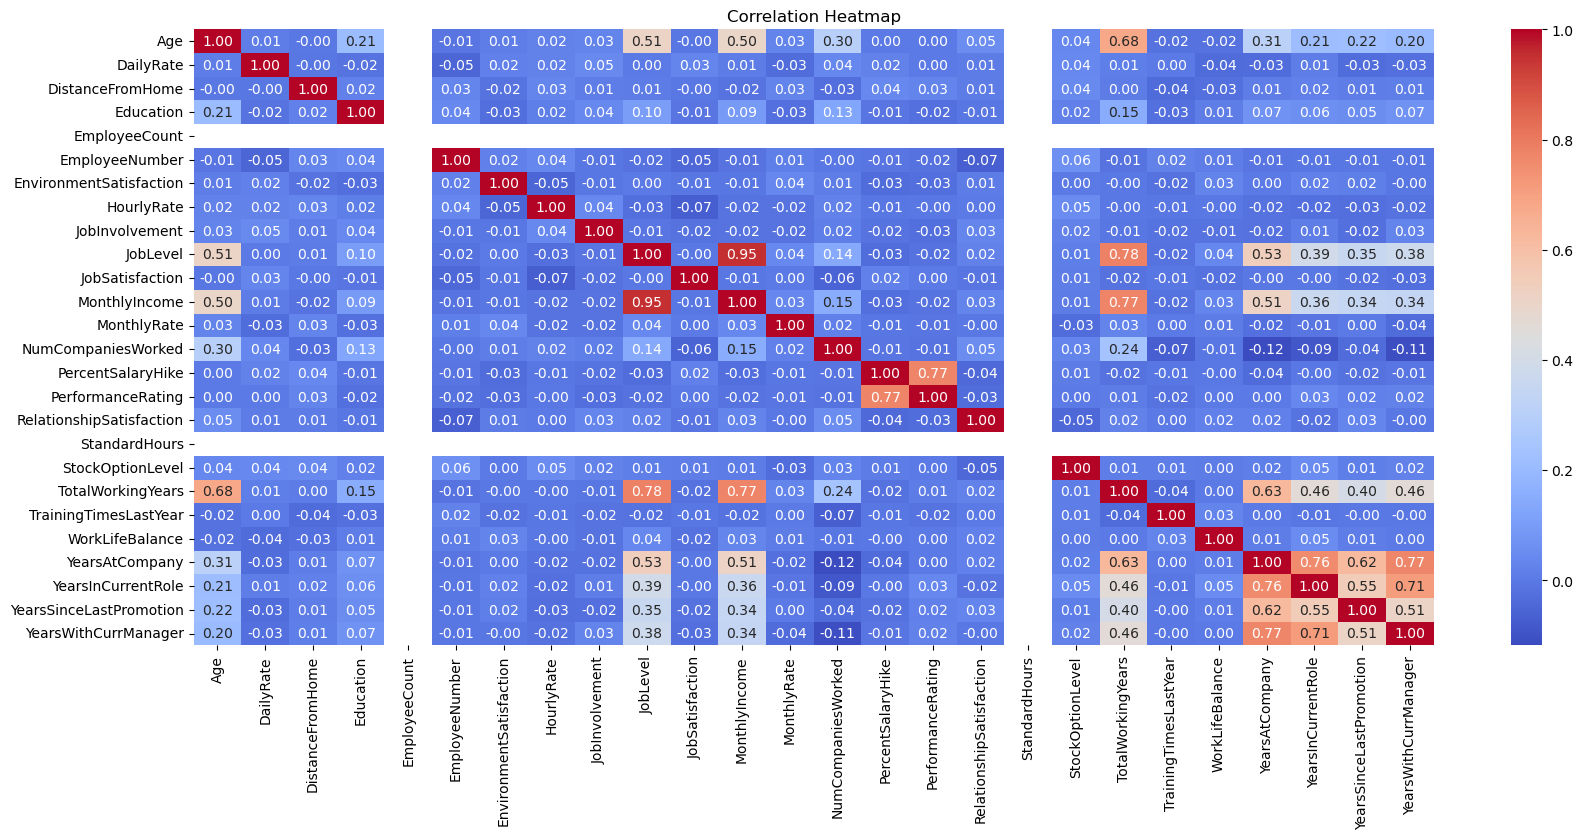

In [850]:
plt.figure(figsize=(20,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')    
plt.show()

In [851]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [852]:
df_yes = df[df['Attrition'] == 'Yes']
df_no  = df[df['Attrition'] == 'No']

In [853]:
df_no_sample = df_no.sample(n=len(df_yes), random_state=42)

In [854]:
df_balanced = pd.concat([df_yes, df_no_sample])

In [855]:
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [856]:
print(df_balanced['Attrition'].value_counts())

Attrition
No     237
Yes    237
Name: count, dtype: int64


In [857]:
df_balanced.shape

(474, 35)

In [858]:
X = df_balanced.drop('Attrition', axis=1)
y = df_balanced['Attrition']

In [859]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [860]:
X_test.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
202,30,Travel_Frequently,464,Research & Development,4,3,Technical Degree,1,514,3,...,3,80,0,3,4,3,1,0,0,0
201,45,Travel_Frequently,1199,Research & Development,7,4,Life Sciences,1,341,1,...,4,80,1,9,1,3,3,2,0,2
181,24,Travel_Frequently,1287,Research & Development,7,3,Life Sciences,1,647,1,...,4,80,1,6,4,3,6,3,1,2
278,40,Non-Travel,1479,Sales,24,3,Life Sciences,1,986,2,...,4,80,0,22,2,2,1,0,0,0
249,33,Travel_Rarely,813,Research & Development,14,3,Medical,1,325,3,...,3,80,1,8,2,1,5,4,0,4


In [861]:
X_test.shape

(95, 34)

In [862]:
y_test

202    Yes
201     No
181    Yes
278    Yes
249    Yes
      ... 
366     No
75     Yes
469    Yes
170    Yes
182     No
Name: Attrition, Length: 95, dtype: object

In [863]:
cat_cols

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [864]:
cat_features = ['BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

In [865]:
num_features = X_train.drop(columns=cat_features).columns.tolist()

In [866]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features)
    ]
)

In [867]:
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans  = preprocessor.transform(X_test)

In [868]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # imbalance handle karega
    random_state=42
)

log_reg.fit(X_train_trans, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [869]:
y_pred = log_reg.predict(X_test_trans)
y_prob = log_reg.predict_proba(X_test_trans)[:, 1]


In [870]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.74      0.83      0.78        48
         Yes       0.80      0.70      0.75        47

    accuracy                           0.77        95
   macro avg       0.77      0.77      0.77        95
weighted avg       0.77      0.77      0.77        95



In [871]:
print(confusion_matrix(y_test, y_pred))

[[40  8]
 [14 33]]


In [872]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.8630319148936171


In [873]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski' 
)

knn.fit(X_train_trans, y_train)

KNeighborsClassifier()

In [874]:
y_pred_knn = knn.predict(X_test_trans)
y_prob_knn = knn.predict_proba(X_test_trans)[:, 1]

In [875]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

          No       0.64      0.79      0.71        48
         Yes       0.72      0.55      0.63        47

    accuracy                           0.67        95
   macro avg       0.68      0.67      0.67        95
weighted avg       0.68      0.67      0.67        95



In [876]:
print(confusion_matrix(y_test, y_pred_knn))

[[38 10]
 [21 26]]


In [877]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))

ROC-AUC: 0.6945921985815602


In [878]:
for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_trans, y_train)
    
    y_pred = knn.predict(X_test_trans)
    
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
    
    recall_yes = report['Yes']['recall']
    
    print(f"k = {k} | Recall (Yes) = {recall_yes:.3f}")

k = 3 | Recall (Yes) = 0.511
k = 5 | Recall (Yes) = 0.553
k = 7 | Recall (Yes) = 0.489
k = 9 | Recall (Yes) = 0.532
k = 11 | Recall (Yes) = 0.574


In [879]:
X_train_nb = X_train_trans
X_test_nb  = X_test_trans

In [880]:
nb = GaussianNB()
nb.fit(X_train_trans, y_train)

GaussianNB()

In [881]:
y_pred_nb = nb.predict(X_test_trans)
y_prob_nb = nb.predict_proba(X_test_trans)[:, 1]

In [882]:
print(classification_report(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nb))

              precision    recall  f1-score   support

          No       0.76      0.52      0.62        48
         Yes       0.63      0.83      0.72        47

    accuracy                           0.67        95
   macro avg       0.69      0.68      0.67        95
weighted avg       0.69      0.67      0.67        95

[[25 23]
 [ 8 39]]
ROC-AUC: 0.8231382978723405
